# Data Leakage Detection Analysis

This notebook performs comprehensive data leakage detection using multiple approaches:
1. Adversarial Validation - Train a model to distinguish between train and test sets
2. Feature Importance Analysis - Identify suspiciously predictive features
3. Temporal Permutation Tests - Ensure no future information leaks into historical data
4. Correlation Analysis - Detect indirect leakage through feature correlations

The presence of data leakage can lead to overoptimistic model performance and poor generalization.

In [1]:
# Import required libraries
import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats as stats

## 1. Data Loading and Preparation

Load feature and target dataframes following the same structure as baseline.ipynb. We'll:
1. Load data from multiple seasons
2. Convert dates to datetime format
3. Align feature and target dataframes
4. Handle missing values

In [2]:
# Load features and targets
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
seasons = sorted(TRAINGING_CONFIG['seasons'])

# Load target data from multiple seasons
target_dfs = [pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") 
              for season in seasons[1:]]

# Convert dates to datetime
for df in target_dfs:
    df['date'] = pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)

# Load and prepare feature data
feature_df = pd.read_csv(features_path)
feature_df['date'] = pd.to_datetime(feature_df['date'])

# Align features and targets
feature_df, target_df = align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

# Handle missing values
feature_df.fillna(-1, inplace=True)

print("Feature DataFrame Shape:", feature_df.shape)
print("Target DataFrame Shape:", target_df.shape)
print("\nFeature columns:", len(feature_df.columns))
print("Date range:", feature_df['date'].min(), "to", feature_df['date'].max())

Feature DataFrame Shape: (2660, 2729)
Target DataFrame Shape: (2660, 13)

Feature columns: 2729
Date range: 2018-08-10 00:00:00 to 2025-05-25 00:00:00


## 2. Adversarial Validation

Adversarial validation helps detect data leakage by training a model to distinguish between training and test sets. 
If the model performs significantly better than random chance (AUC > 0.5), it suggests:
1. Potential data leakage
2. Distribution shift between train and test sets
3. Temporal patterns that might need attention

In [3]:
def perform_adversarial_validation(feature_df, test_size=0.2, n_splits=5):
    """
    Perform adversarial validation to detect potential data leakage.
    Returns AUC scores and feature importances.
    """
    # Create temporal split
    split_date = feature_df['date'].sort_values().iloc[int(len(feature_df) * (1 - test_size))]
    
    # Create binary labels: 0 for train, 1 for test
    is_test = (feature_df['date'] >= split_date).astype(int)
    
    # Prepare features (exclude date and other non-feature columns)
    feature_cols = [col for col in feature_df.columns 
                   if col not in TRAINGING_CONFIG['key_columns']]
    X = feature_df[feature_cols]
    
    # Initialize results storage
    aucs = []
    feature_importances = []
    
    # Perform k-fold CV for robust estimates
    for i in range(n_splits):
        # Split data for validation
        X_train, X_val, y_train, y_val = train_test_split(
            X, is_test, test_size=0.2, random_state=i
        )
        
        # Train Random Forest
        rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=i)
        rf.fit(X_train, y_train)
        
        # Get predictions and AUC
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        aucs.append(auc)
        
        # Store feature importances
        feature_importances.append(rf.feature_importances_)
    
    # Average results across splits
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    mean_importances = np.mean(feature_importances, axis=0)
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': mean_importances
    }).sort_values('importance', ascending=False)
    
    return mean_auc, std_auc, importance_df

# Run adversarial validation
mean_auc, std_auc, importances = perform_adversarial_validation(feature_df)

print(f"Adversarial Validation AUC: {mean_auc:.3f} ± {std_auc:.3f}")
print("\nTop 20 most important features for distinguishing train/test sets:")
print(importances.head(20))

# Plot feature importances
plt.figure(figsize=(12, 6))
sns.barplot(data=importances.head(20), x='importance', y='feature')
plt.title('Top 20 Features for Distinguishing Train/Test Sets')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analyze AUC significance
null_hypothesis_auc = 0.5
z_score = (mean_auc - null_hypothesis_auc) / (std_auc / np.sqrt(5))  # 5 splits
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # two-tailed test

print(f"\nStatistical Analysis:")
print(f"Z-score: {z_score:.3f}")
print(f"P-value: {p_value:.3f}")
print("Interpretation:")
if p_value < 0.05:
    print("WARNING: Significant evidence of data leakage or distribution shift detected!")
else:
    print("No significant evidence of data leakage detected.")

KeyboardInterrupt: 

## 3. Permutation Tests for Feature Importance

Permutation tests help identify features that might be "too good to be true" by:
1. Computing feature importance scores for each target variable
2. Comparing against randomized target permutations
3. Identifying features with suspiciously high predictive power

Features with very low p-values might be leaking information from the target.


Analyzing target: home_goals


Running permutations for home_goals: 100%|██████████| 100/100 [00:46<00:00,  2.15it/s]



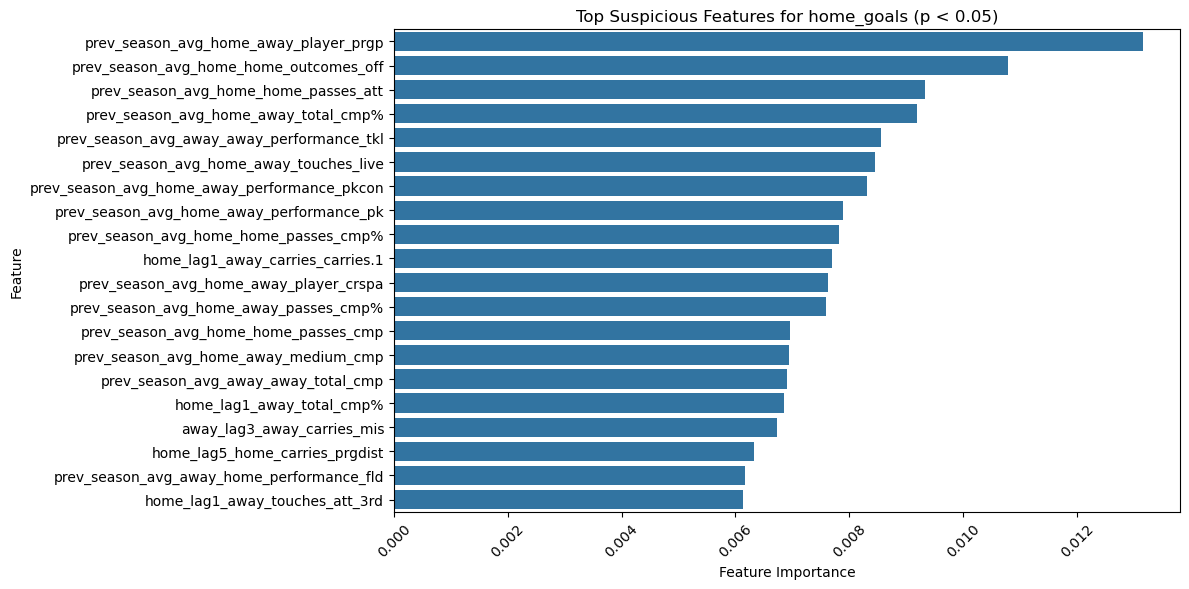


Top 10 potentially problematic features:
                                         feature  importance  p_value
175        prev_season_avg_home_away_player_prgp    0.013153     0.00
93        prev_season_avg_home_home_outcomes_off    0.010785     0.00
55          prev_season_avg_home_home_passes_att    0.009326     0.00
178         prev_season_avg_home_away_total_cmp%    0.009194     0.00
369    prev_season_avg_away_away_performance_tkl    0.008561     0.00
224       prev_season_avg_home_away_touches_live    0.008447     0.01
250  prev_season_avg_home_away_performance_pkcon    0.008308     0.00
149     prev_season_avg_home_away_performance_pk    0.007884     0.00
56         prev_season_avg_home_home_passes_cmp%    0.007824     0.02
662             home_lag1_away_carries_carries.1    0.007703     0.01

Analyzing target: away_goals


Running permutations for away_goals: 100%|██████████| 100/100 [00:46<00:00,  2.14it/s]



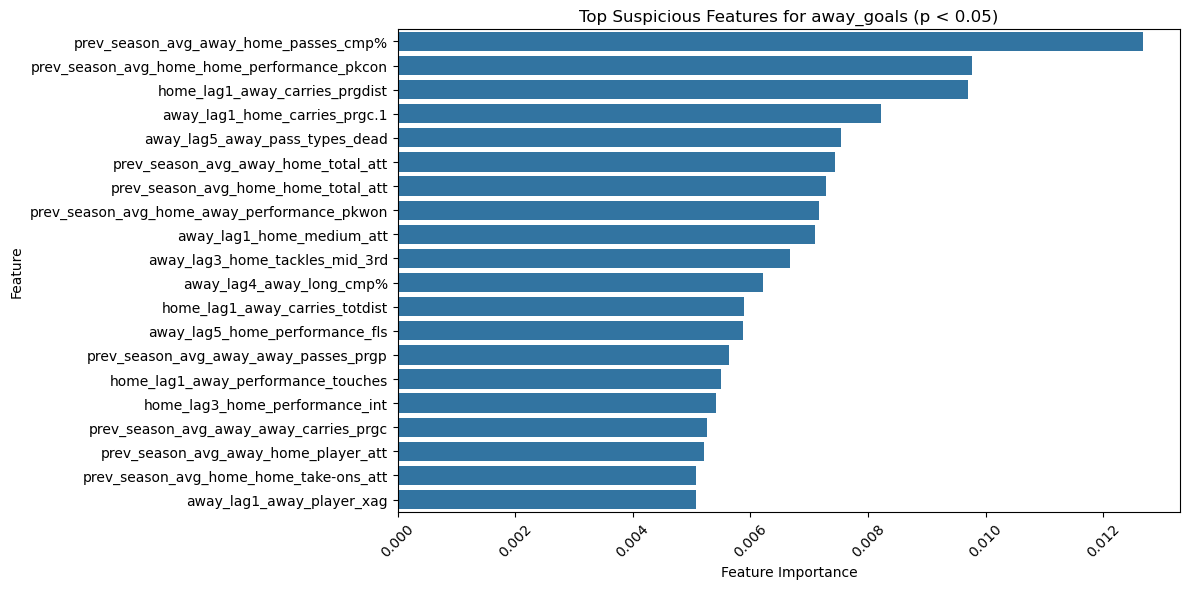


Top 10 potentially problematic features:
                                          feature  importance  p_value
272         prev_season_avg_away_home_passes_cmp%    0.012674     0.00
143   prev_season_avg_home_home_performance_pkcon    0.009765     0.00
664                home_lag1_away_carries_prgdist    0.009697     0.00
1633                away_lag1_home_carries_prgc.1    0.008228     0.01
2559               away_lag5_away_pass_types_dead    0.007539     0.02
286           prev_season_avg_away_home_total_att    0.007431     0.00
70            prev_season_avg_home_home_total_att    0.007287     0.00
249   prev_season_avg_home_away_performance_pkwon    0.007164     0.00
1585                    away_lag1_home_medium_att    0.007091     0.00
2039               away_lag3_home_tackles_mid_3rd    0.006674     0.00

Analyzing target: home_corners


Running permutations for home_corners: 100%|██████████| 100/100 [00:48<00:00,  2.08it/s]



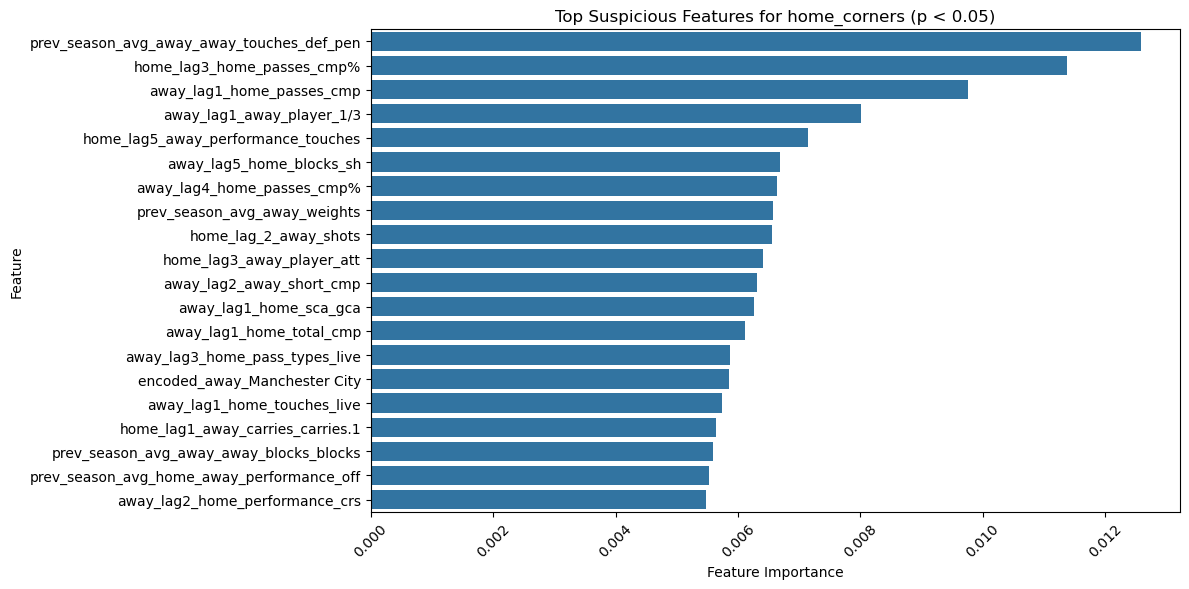


Top 10 potentially problematic features:
                                        feature  importance  p_value
435   prev_season_avg_away_away_touches_def_pen    0.012592     0.00
918                  home_lag3_home_passes_cmp%    0.011379     0.00
1561                  away_lag1_home_passes_cmp    0.009752     0.00
1679                  away_lag1_away_player_1/3    0.008015     0.00
1444         home_lag5_away_performance_touches    0.007145     0.04
2476                   away_lag5_home_blocks_sh    0.006686     0.00
2208                 away_lag4_home_passes_cmp%    0.006630     0.01
473                prev_season_avg_away_weights    0.006564     0.00
2643                      home_lag_2_away_shots    0.006550     0.00
1052                  home_lag3_away_player_att    0.006409     0.01

Analyzing target: away_corners


Running permutations for away_corners: 100%|██████████| 100/100 [00:47<00:00,  2.09it/s]



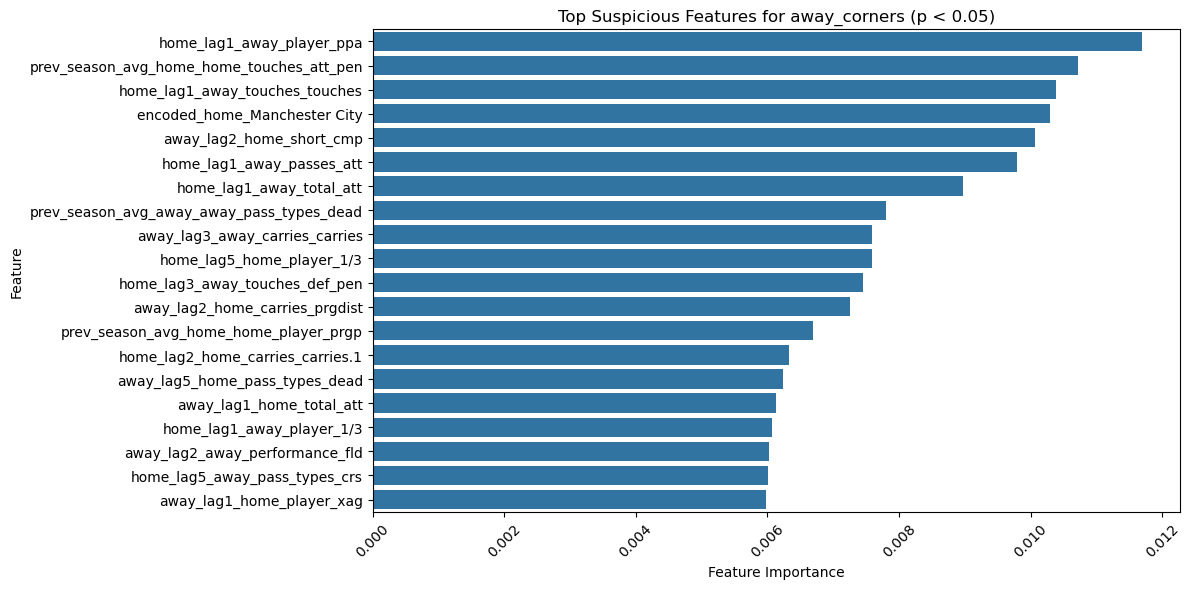


Top 10 potentially problematic features:
                                        feature  importance  p_value
605                   home_lag1_away_player_ppa    0.011688     0.00
116   prev_season_avg_home_home_touches_att_pen    0.010723     0.00
650              home_lag1_away_touches_touches    0.010387     0.00
10                 encoded_home_Manchester City    0.010300     0.00
1796                   away_lag2_home_short_cmp    0.010071     0.00
594                   home_lag1_away_passes_att    0.009797     0.00
609                    home_lag1_away_total_att    0.008972     0.01
408   prev_season_avg_away_away_pass_types_dead    0.007810     0.00
2102             away_lag3_away_carries_carries    0.007593     0.02
1357                  home_lag5_home_player_1/3    0.007584     0.01

Analyzing target: home_cards


Running permutations for home_cards: 100%|██████████| 100/100 [00:46<00:00,  2.14it/s]



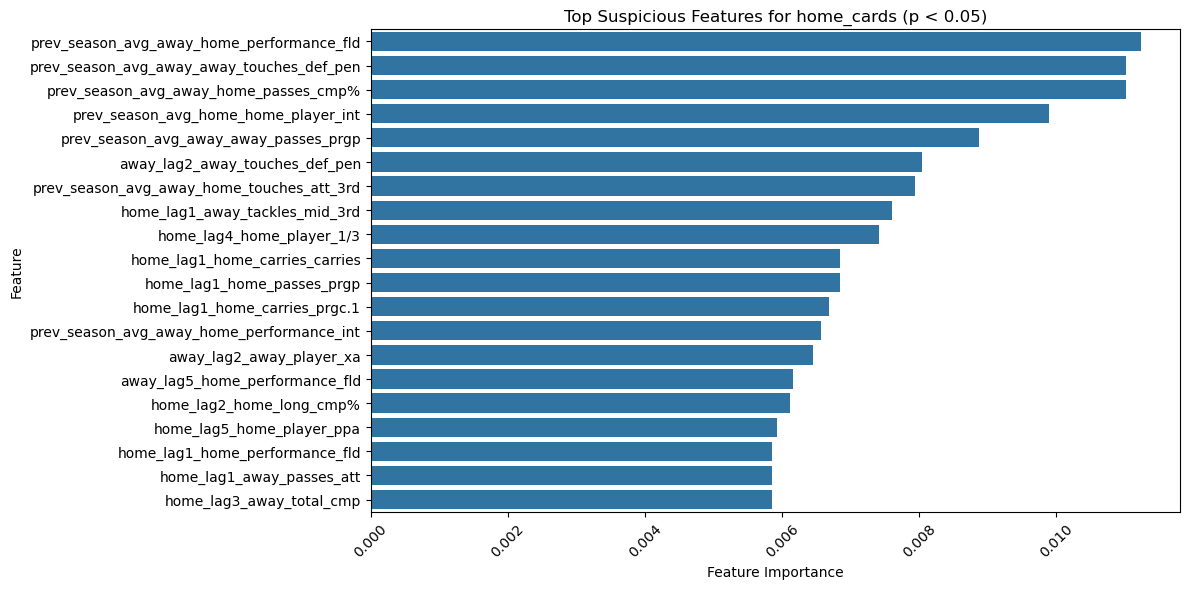


Top 10 potentially problematic features:
                                        feature  importance  p_value
353   prev_season_avg_away_home_performance_fld    0.011246     0.00
435   prev_season_avg_away_away_touches_def_pen    0.011019     0.00
272       prev_season_avg_away_home_passes_cmp%    0.011015     0.00
95         prev_season_avg_home_home_player_int    0.009902     0.00
380       prev_season_avg_away_away_passes_prgp    0.008877     0.00
1941             away_lag2_away_touches_def_pen    0.008039     0.00
331   prev_season_avg_away_home_touches_att_3rd    0.007948     0.00
641              home_lag1_away_tackles_mid_3rd    0.007612     0.00
1142                  home_lag4_home_player_1/3    0.007409     0.00
490              home_lag1_home_carries_carries    0.006850     0.03

Analyzing target: away_cards


Running permutations for away_cards: 100%|██████████| 100/100 [00:47<00:00,  2.09it/s]



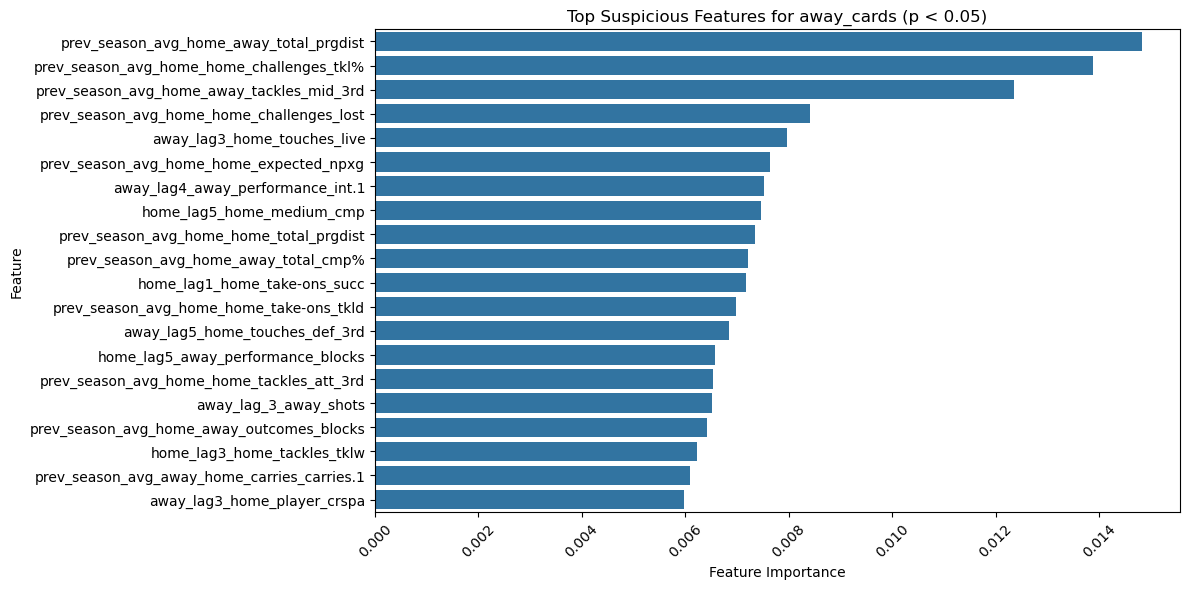


Top 10 potentially problematic features:
                                        feature  importance  p_value
180     prev_season_avg_home_away_total_prgdist    0.014826     0.00
106   prev_season_avg_home_home_challenges_tkl%    0.013882     0.00
209   prev_season_avg_home_away_tackles_mid_3rd    0.012365     0.00
107   prev_season_avg_home_home_challenges_lost    0.008407     0.00
2054                away_lag3_home_touches_live    0.007969     0.00
50      prev_season_avg_home_home_expected_npxg    0.007631     0.00
2399           away_lag4_away_performance_int.1    0.007519     0.00
1369                  home_lag5_home_medium_cmp    0.007466     0.01
73      prev_season_avg_home_home_total_prgdist    0.007350     0.00
178        prev_season_avg_home_away_total_cmp%    0.007213     0.00

Analyzing target: home_shots


Running permutations for home_shots: 100%|██████████| 100/100 [00:51<00:00,  1.93it/s]



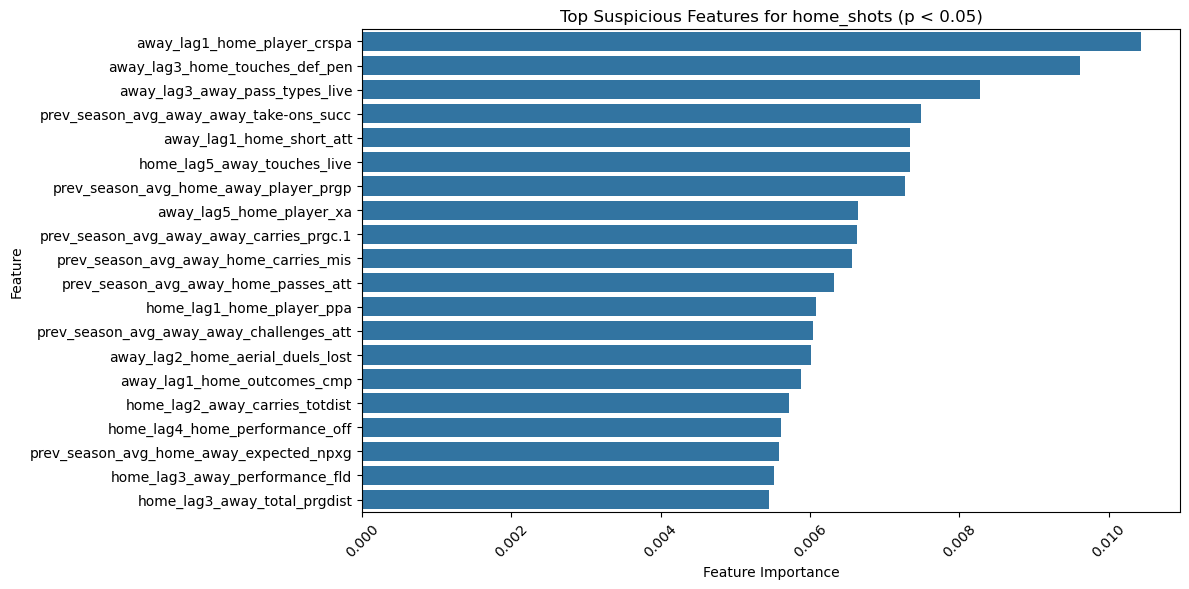


Top 10 potentially problematic features:
                                       feature  importance  p_value
1574               away_lag1_home_player_crspa    0.010435     0.00
2049            away_lag3_home_touches_def_pen    0.009612     0.00
2128            away_lag3_away_pass_types_live    0.008275     0.01
384    prev_season_avg_away_away_take-ons_succ    0.007494     0.00
1582                  away_lag1_home_short_att    0.007343     0.00
1516               home_lag5_away_touches_live    0.007339     0.01
175      prev_season_avg_home_away_player_prgp    0.007275     0.01
2430                  away_lag5_home_player_xa    0.006645     0.02
449   prev_season_avg_away_away_carries_prgc.1    0.006634     0.01
345      prev_season_avg_away_home_carries_mis    0.006562     0.00

Analyzing target: away_shots


Running permutations for away_shots: 100%|██████████| 100/100 [00:49<00:00,  2.00it/s]



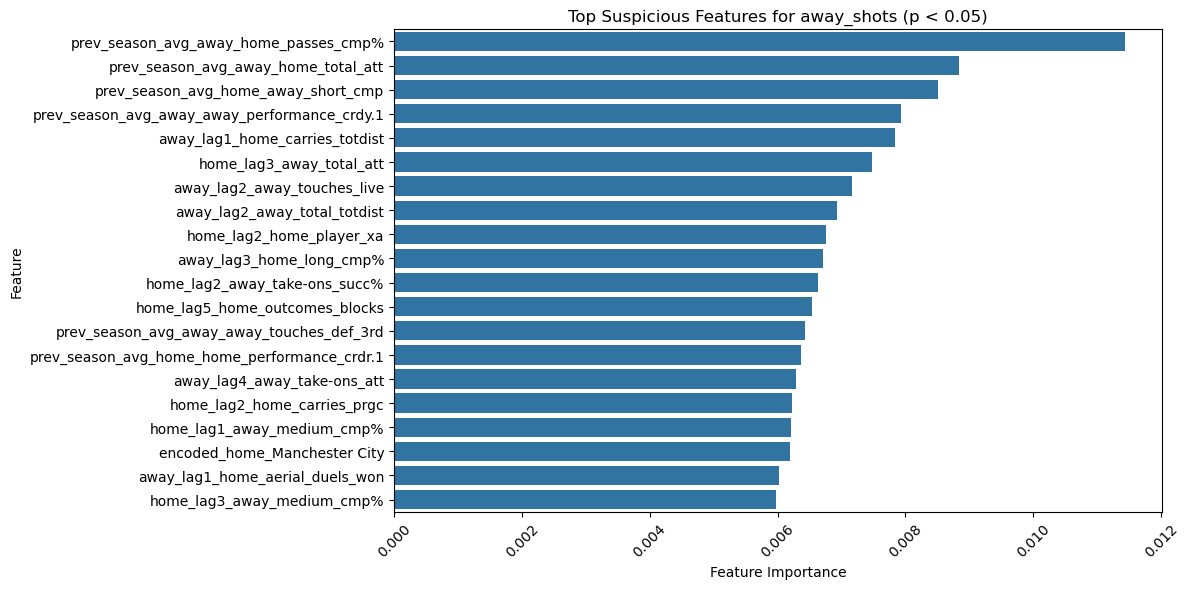


Top 10 potentially problematic features:
                                           feature  importance  p_value
272          prev_season_avg_away_home_passes_cmp%    0.011440     0.00
286            prev_season_avg_away_home_total_att    0.008845     0.00
181            prev_season_avg_home_away_short_cmp    0.008511     0.00
456   prev_season_avg_away_away_performance_crdy.1    0.007925     0.00
1631                away_lag1_home_carries_totdist    0.007842     0.03
1039                      home_lag3_away_total_att    0.007476     0.00
1946                   away_lag2_away_touches_live    0.007161     0.01
1901                  away_lag2_away_total_totdist    0.006927     0.03
710                       home_lag2_home_player_xa    0.006757     0.00
2019                      away_lag3_home_long_cmp%    0.006716     0.00

Analyzing target: home_sots


Running permutations for home_sots: 100%|██████████| 100/100 [00:48<00:00,  2.06it/s]



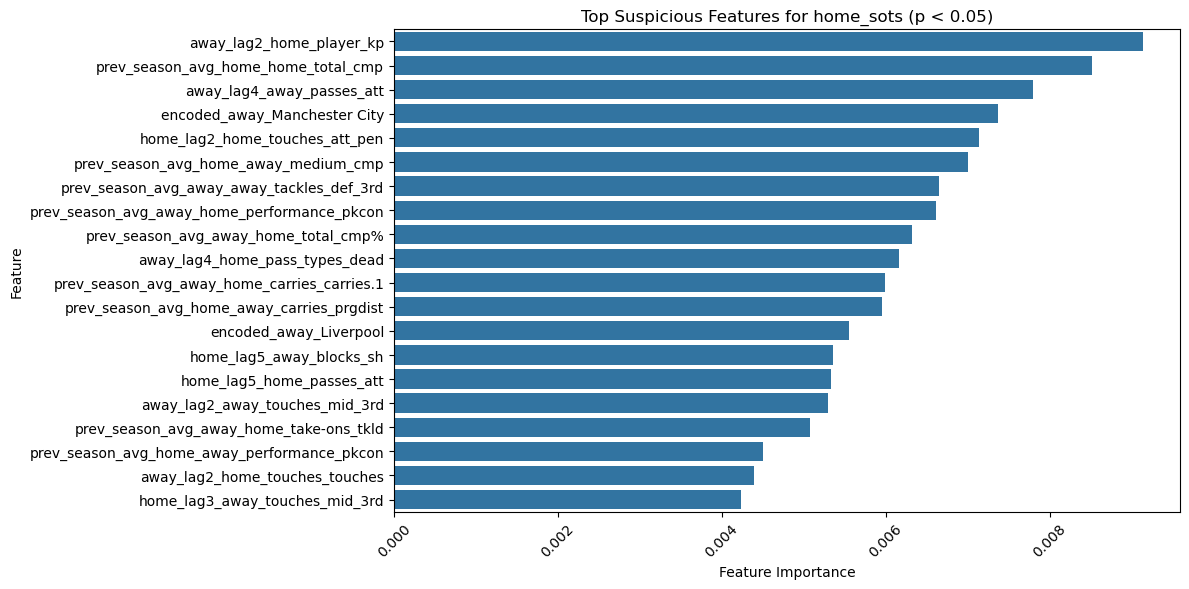


Top 10 potentially problematic features:
                                          feature  importance  p_value
1786                     away_lag2_home_player_kp    0.009133     0.00
69            prev_season_avg_home_home_total_cmp    0.008520     0.00
2314                    away_lag4_away_passes_att    0.007798     0.00
31                   encoded_away_Manchester City    0.007365     0.00
763                home_lag2_home_touches_att_pen    0.007143     0.00
184          prev_season_avg_home_away_medium_cmp    0.007005     0.00
424     prev_season_avg_away_away_tackles_def_3rd    0.006650     0.02
359   prev_season_avg_away_home_performance_pkcon    0.006610     0.00
287          prev_season_avg_away_home_total_cmp%    0.006323     0.01
2237               away_lag4_home_pass_types_dead    0.006156     0.00

Analyzing target: away_sots


Running permutations for away_sots: 100%|██████████| 100/100 [00:47<00:00,  2.10it/s]



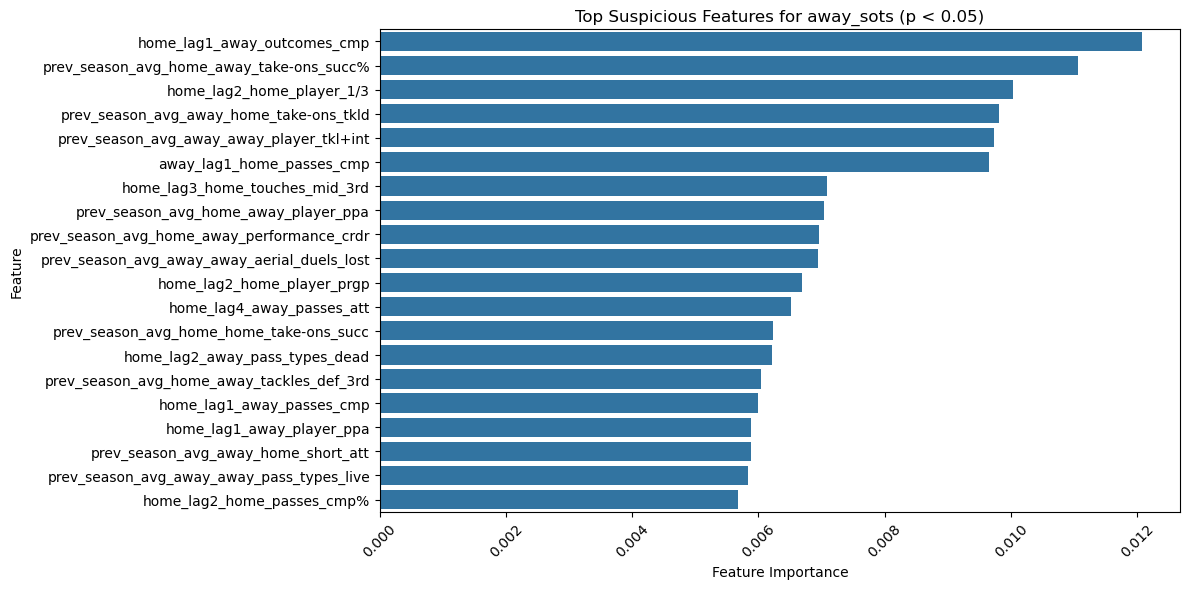


Top 10 potentially problematic features:
                                          feature  importance  p_value
631                   home_lag1_away_outcomes_cmp    0.012074     0.00
227      prev_season_avg_home_away_take-ons_succ%    0.011055     0.00
712                     home_lag2_home_player_1/3    0.010030     0.00
337       prev_season_avg_away_home_take-ons_tkld    0.009808     0.00
419      prev_season_avg_away_away_player_tkl+int    0.009735     0.00
1561                    away_lag1_home_passes_cmp    0.009646     0.00
976                home_lag3_home_touches_mid_3rd    0.007082     0.01
173          prev_season_avg_home_away_player_ppa    0.007040     0.00
151    prev_season_avg_home_away_performance_crdr    0.006953     0.00
470   prev_season_avg_away_away_aerial_duels_lost    0.006945     0.00


In [ ]:
def perform_permutation_test(feature_df, target_df, target_col, n_permutations=100):
    """
    Perform permutation test to detect suspiciously predictive features.
    Returns feature importance scores and their statistical significance.
    """
    # Prepare features
    feature_cols = [col for col in feature_df.columns 
                   if col not in TRAINGING_CONFIG['key_columns']]
    X = feature_df[feature_cols]
    y = target_df[target_col]
    
    # Original feature importance scores
    rf = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
    rf.fit(X, y)
    original_importance = rf.feature_importances_
    
    # Permutation scores
    perm_importance = np.zeros((n_permutations, len(feature_cols)))
    
    for i in tqdm(range(n_permutations), desc=f"Running permutations for {target_col}"):
        y_perm = np.random.permutation(y)
        rf_perm = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
        rf_perm.fit(X, y_perm)
        perm_importance[i] = rf_perm.feature_importances_
    
    # Calculate p-values
    p_values = np.mean(perm_importance >= original_importance.reshape(1, -1), axis=0)
    
    # Create results DataFrame
    results = pd.DataFrame({
        'feature': feature_cols,
        'importance': original_importance,
        'p_value': p_values,
        'significant': p_values < 0.05
    }).sort_values('importance', ascending=False)
    
    return results

# Run permutation test for each target column
target_columns = [col for col in target_df.columns 
                 if col not in TRAINGING_CONFIG['key_columns']]

for target_col in target_columns:
    print(f"\nAnalyzing target: {target_col}")
    results = perform_permutation_test(feature_df, target_df, target_col)
    
    # Plot results
    plt.figure(figsize=(12, 6))
    suspicious_features = results[results['significant']].head(20)
    sns.barplot(data=suspicious_features, x='importance', y='feature')
    plt.title(f'Top Suspicious Features for {target_col} (p < 0.05)')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 potentially problematic features:")
    print(suspicious_features[['feature', 'importance', 'p_value']].head(10))

## 4. Temporal Correlation Analysis

This section analyzes temporal relationships between features and targets to detect:
1. Forward-looking features that might leak future information
2. Unexpected correlations across time periods
3. Temporal dependencies that might indicate data leakage

/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: Runtime

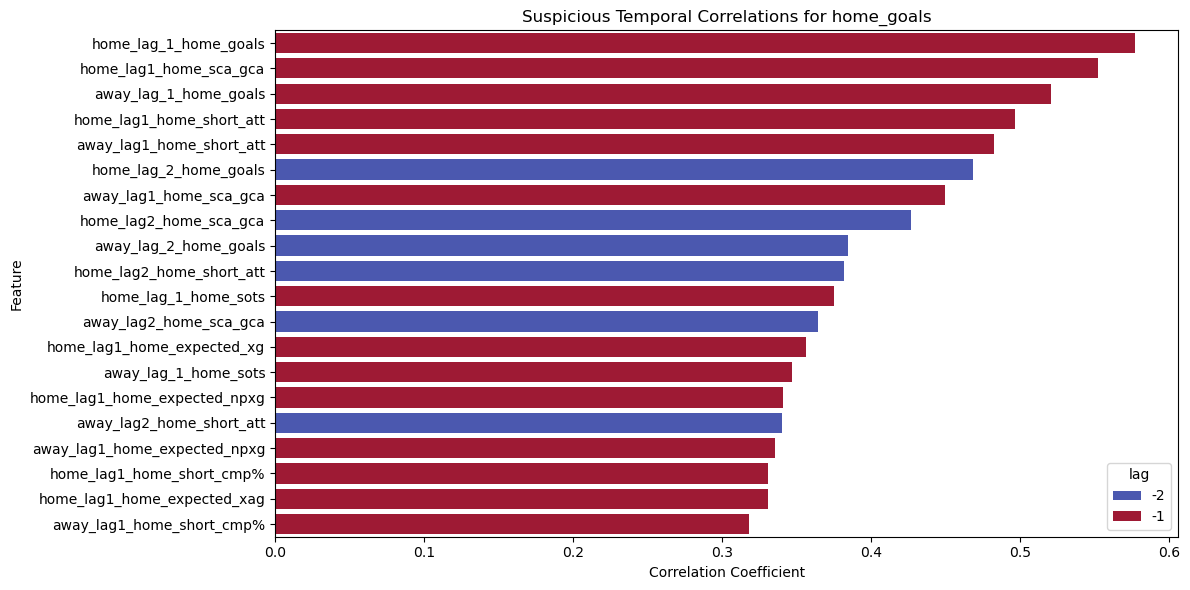


Suspicious correlations for home_goals:
                        feature  lag  correlation
10505     home_lag_1_home_goals   -1     0.577127
1941     home_lag1_home_sca_gca   -1     0.552047
10705     away_lag_1_home_goals   -1     0.520438
2029   home_lag1_home_short_att   -1     0.496379
6329   away_lag1_home_short_att   -1     0.482731
10544     home_lag_2_home_goals   -2     0.468051
6241     away_lag1_home_sca_gca   -1     0.449360
2800     home_lag2_home_sca_gca   -2     0.426438
10744     away_lag_2_home_goals   -2     0.384211
2888   home_lag2_home_short_att   -2     0.381505


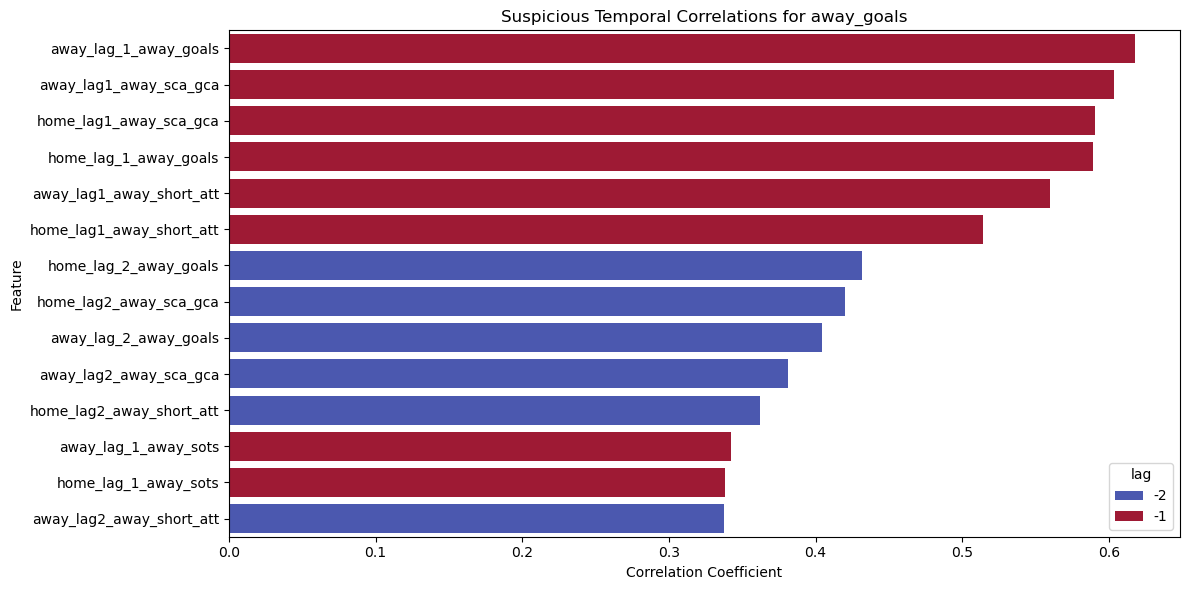


Suspicious correlations for away_goals:
                        feature  lag  correlation
21613     away_lag_1_away_goals   -1     0.617552
17573    away_lag1_away_sca_gca   -1     0.603652
13273    home_lag1_away_sca_gca   -1     0.590241
21413     home_lag_1_away_goals   -1     0.589431
17661  away_lag1_away_short_att   -1     0.560000
13361  home_lag1_away_short_att   -1     0.514094
21452     home_lag_2_away_goals   -2     0.431523
14132    home_lag2_away_sca_gca   -2     0.420340
21652     away_lag_2_away_goals   -2     0.404569
18432    away_lag2_away_sca_gca   -2     0.381268


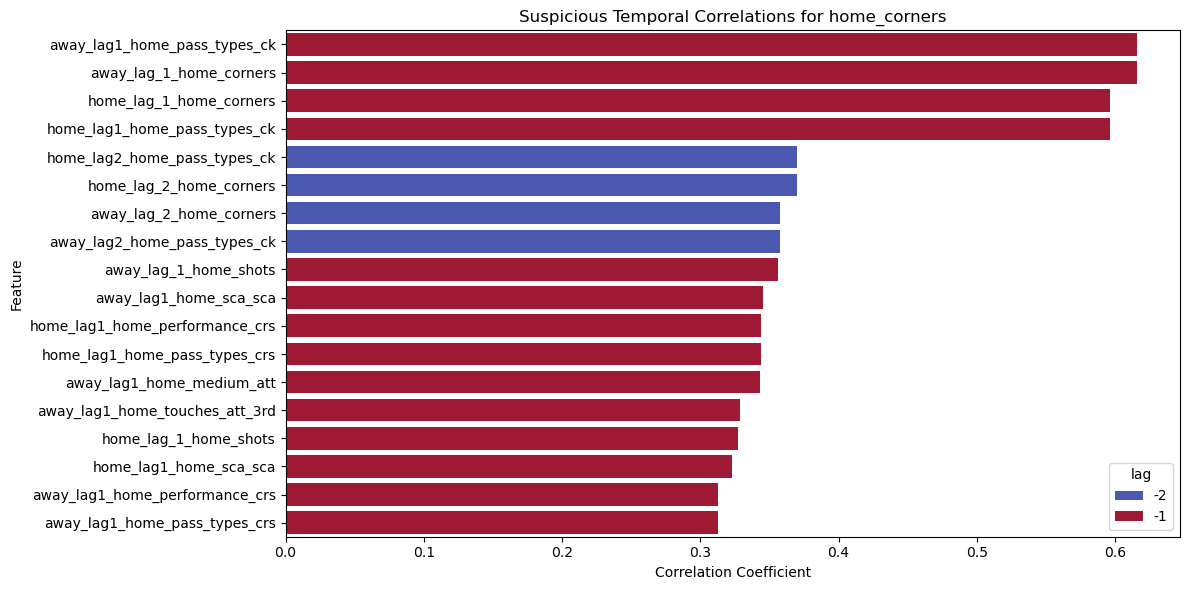


Suspicious correlations for home_corners:
                            feature  lag  correlation
28201  away_lag1_home_pass_types_ck   -1     0.616165
32521       away_lag_1_home_corners   -1     0.616165
32321       home_lag_1_home_corners   -1     0.596210
23901  home_lag1_home_pass_types_ck   -1     0.596210
24760  home_lag2_home_pass_types_ck   -2     0.369636
32360       home_lag_2_home_corners   -2     0.369636
32560       away_lag_2_home_corners   -2     0.357944
29060  away_lag2_home_pass_types_ck   -2     0.357944
32537         away_lag_1_home_shots   -1     0.356441
28045        away_lag1_home_sca_sca   -1     0.345431


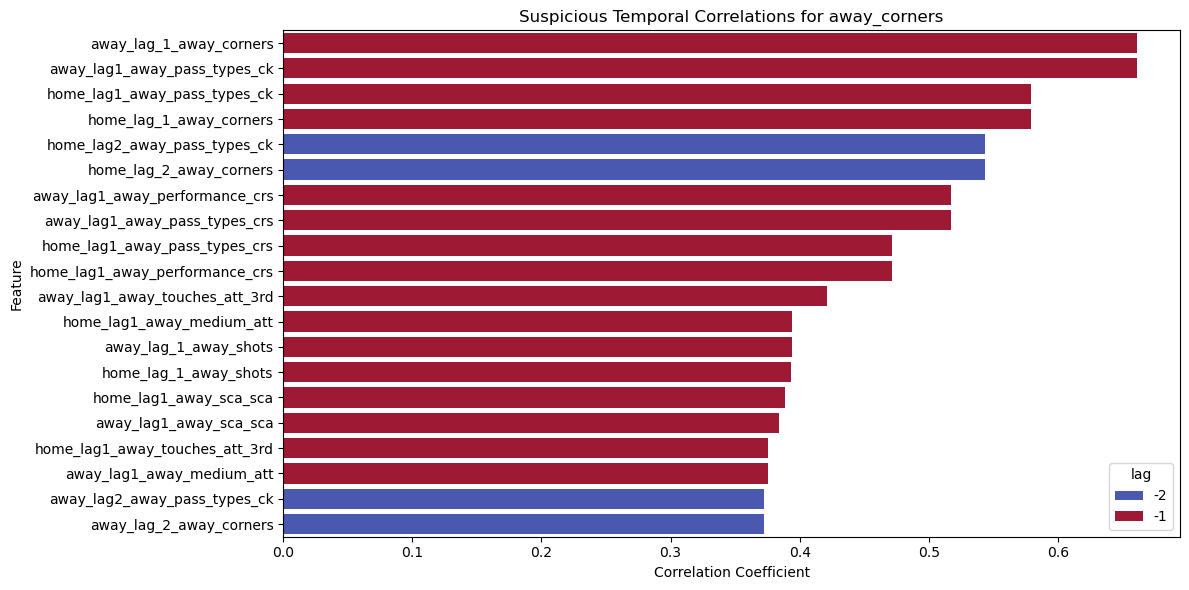


Suspicious correlations for away_corners:
                              feature  lag  correlation
43429         away_lag_1_away_corners   -1     0.661506
39533    away_lag1_away_pass_types_ck   -1     0.661506
35233    home_lag1_away_pass_types_ck   -1     0.579337
43229         home_lag_1_away_corners   -1     0.579337
36092    home_lag2_away_pass_types_ck   -2     0.543494
43268         home_lag_2_away_corners   -2     0.543494
39725  away_lag1_away_performance_crs   -1     0.516894
39525   away_lag1_away_pass_types_crs   -1     0.516894
35225   home_lag1_away_pass_types_crs   -1     0.471372
35425  home_lag1_away_performance_crs   -1     0.471372


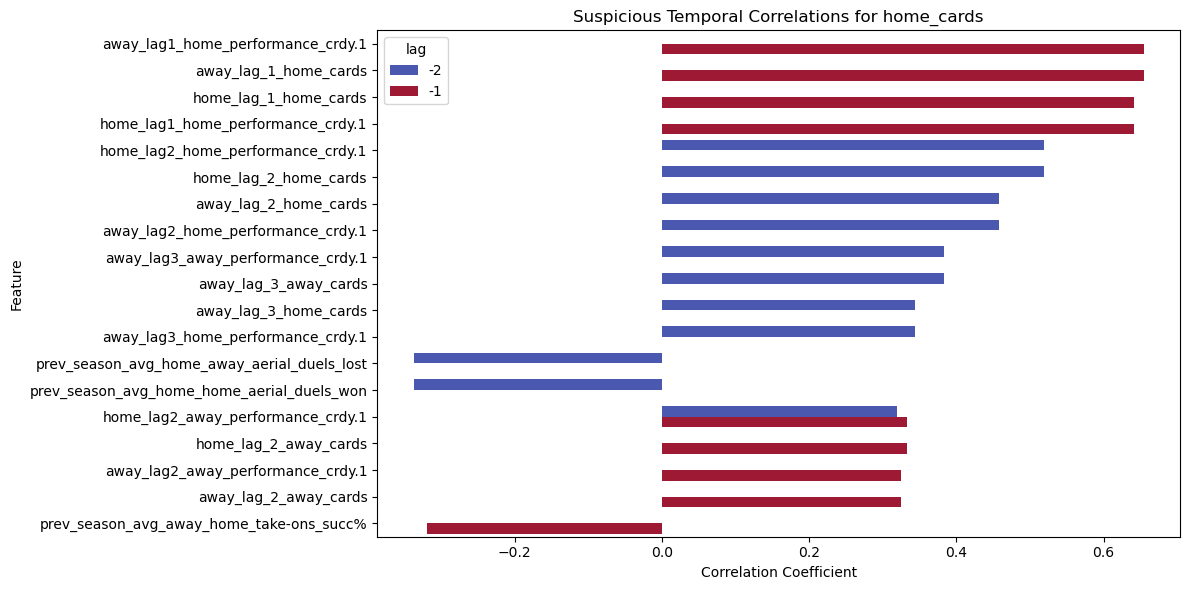


Suspicious correlations for home_cards:
                                 feature  lag  correlation
50177  away_lag1_home_performance_crdy.1   -1     0.654127
54337              away_lag_1_home_cards   -1     0.654127
54137              home_lag_1_home_cards   -1     0.641001
45877  home_lag1_home_performance_crdy.1   -1     0.641001
46736  home_lag2_home_performance_crdy.1   -2     0.518451
54176              home_lag_2_home_cards   -2     0.518451
54376              away_lag_2_home_cards   -2     0.457850
51036  away_lag2_home_performance_crdy.1   -2     0.457850
52324  away_lag3_away_performance_crdy.1   -2     0.383289
54420              away_lag_3_away_cards   -2     0.383289


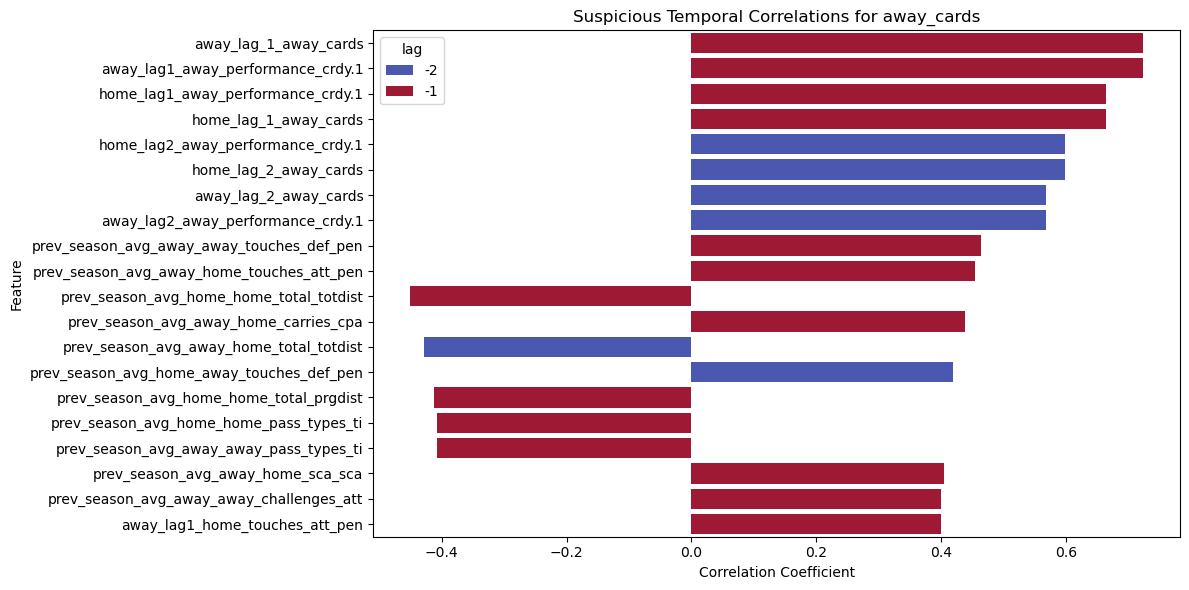


Suspicious correlations for away_cards:
                                         feature  lag  correlation
65245                      away_lag_1_away_cards   -1     0.724248
61509          away_lag1_away_performance_crdy.1   -1     0.724248
57209          home_lag1_away_performance_crdy.1   -1     0.664141
65045                      home_lag_1_away_cards   -1     0.664141
58068          home_lag2_away_performance_crdy.1   -2     0.597971
65084                      home_lag_2_away_cards   -2     0.597971
65284                      away_lag_2_away_cards   -2     0.568663
62368          away_lag2_away_performance_crdy.1   -2     0.568663
56261  prev_season_avg_away_away_touches_def_pen   -1     0.464511
55849  prev_season_avg_away_home_touches_att_pen   -1     0.454581


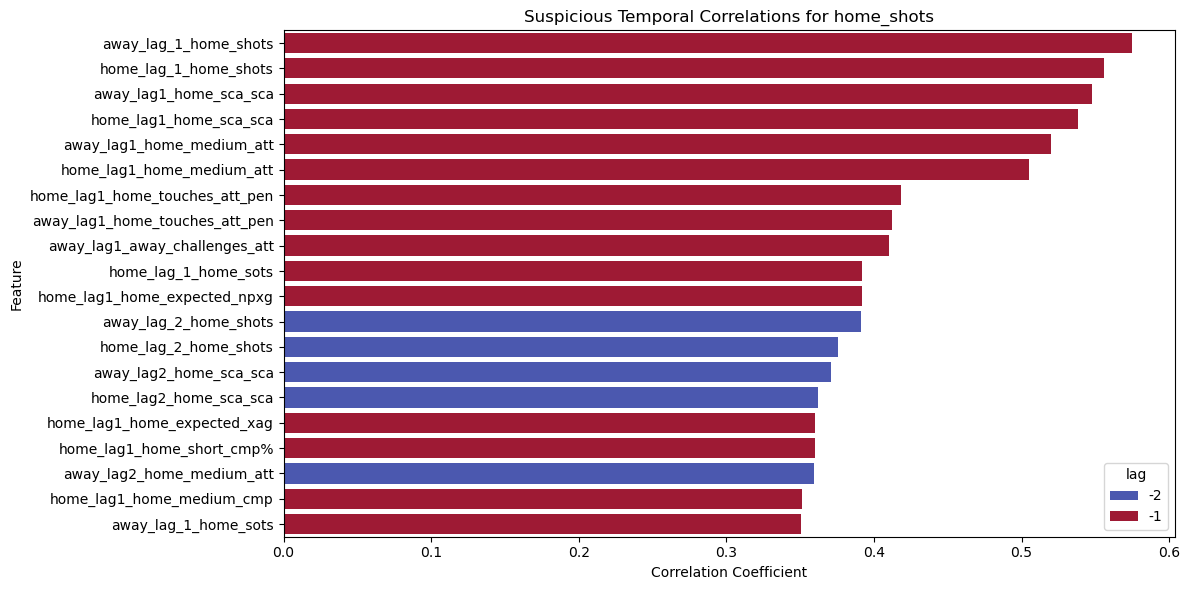


Suspicious correlations for home_shots:
                              feature  lag  correlation
76153           away_lag_1_home_shots   -1     0.575126
75953           home_lag_1_home_shots   -1     0.555977
71661          away_lag1_home_sca_sca   -1     0.547408
67361          home_lag1_home_sca_sca   -1     0.537974
71765       away_lag1_home_medium_att   -1     0.519818
67465       home_lag1_home_medium_att   -1     0.505316
67617  home_lag1_home_touches_att_pen   -1     0.418047
71917  away_lag1_home_touches_att_pen   -1     0.412184
72301   away_lag1_away_challenges_att   -1     0.410487
75961            home_lag_1_home_sots   -1     0.391960


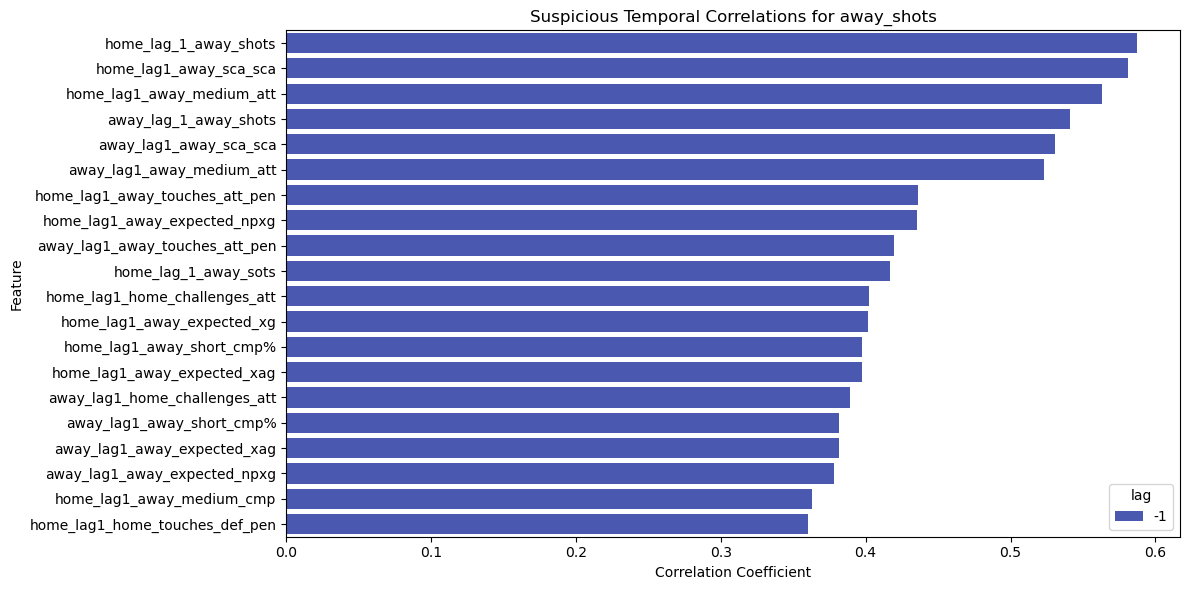


Suspicious correlations for away_shots:
                              feature  lag  correlation
86861           home_lag_1_away_shots   -1     0.587616
78693          home_lag1_away_sca_sca   -1     0.581095
78797       home_lag1_away_medium_att   -1     0.562914
87061           away_lag_1_away_shots   -1     0.541392
82993          away_lag1_away_sca_sca   -1     0.530594
83097       away_lag1_away_medium_att   -1     0.523188
78949  home_lag1_away_touches_att_pen   -1     0.436280
78685    home_lag1_away_expected_npxg   -1     0.435623
83249  away_lag1_away_touches_att_pen   -1     0.419419
86869            home_lag_1_away_sots   -1     0.417114


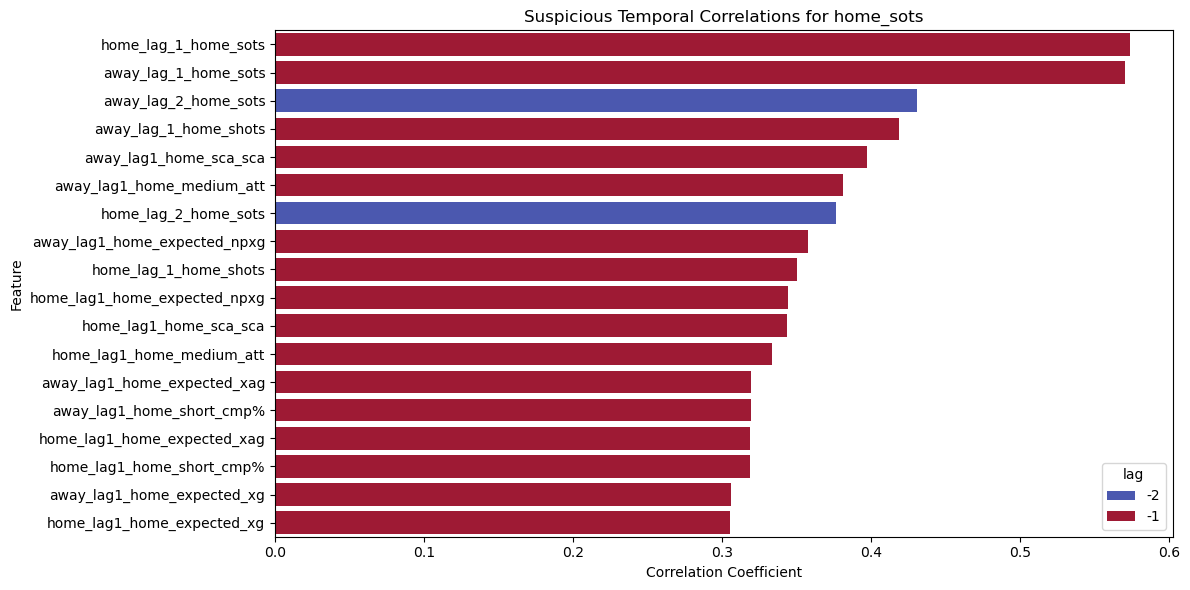


Suspicious correlations for home_sots:
                            feature  lag  correlation
97769          home_lag_1_home_sots   -1     0.573642
97969          away_lag_1_home_sots   -1     0.570588
98008          away_lag_2_home_sots   -2     0.431033
97961         away_lag_1_home_shots   -1     0.418926
93469        away_lag1_home_sca_sca   -1     0.397261
93573     away_lag1_home_medium_att   -1     0.381378
97808          home_lag_2_home_sots   -2     0.376675
93461  away_lag1_home_expected_npxg   -1     0.357707
97761         home_lag_1_home_shots   -1     0.350194
89161  home_lag1_home_expected_npxg   -1     0.344127


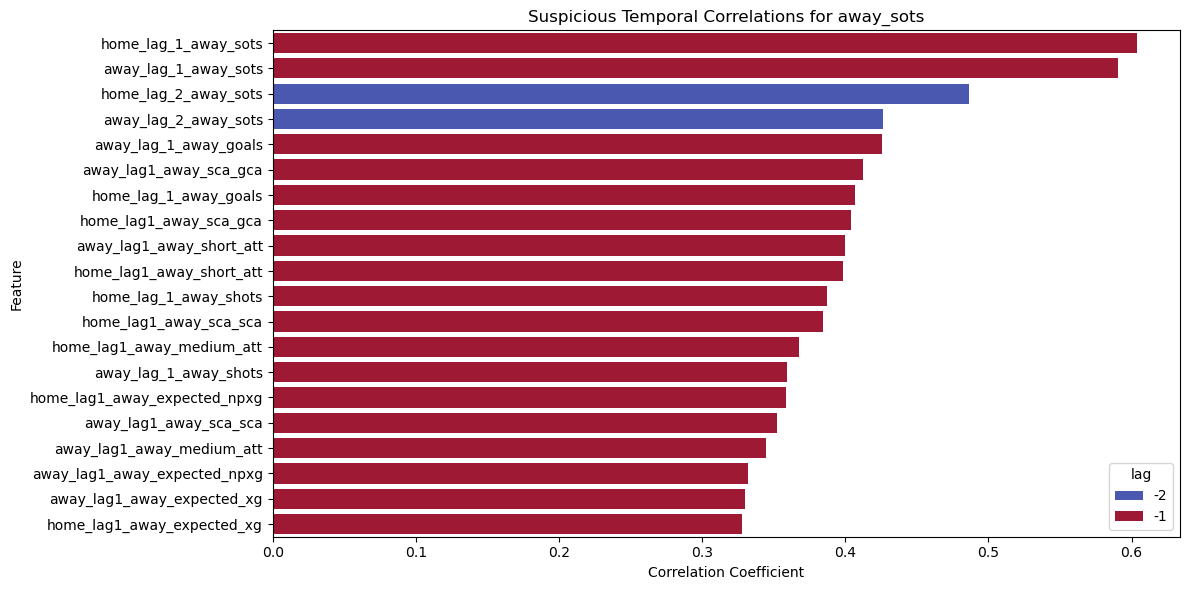


Suspicious correlations for away_sots:
                         feature  lag  correlation
108677      home_lag_1_away_sots   -1     0.603664
108877      away_lag_1_away_sots   -1     0.590463
108716      home_lag_2_away_sots   -2     0.486511
108916      away_lag_2_away_sots   -2     0.426119
108845     away_lag_1_away_goals   -1     0.425517
104805    away_lag1_away_sca_gca   -1     0.412479
108645     home_lag_1_away_goals   -1     0.406623
100505    home_lag1_away_sca_gca   -1     0.403944
104893  away_lag1_away_short_att   -1     0.400048
100593  home_lag1_away_short_att   -1     0.398588


In [ ]:
def analyze_temporal_correlations(feature_df, target_df, window_size='7D'):
    """
    Analyze temporal correlations between features and targets.
    Returns correlation matrix and suspicious correlations.
    """
    # Prepare data
    feature_cols = [col for col in feature_df.columns 
                   if col not in TRAINGING_CONFIG['key_columns']]
    target_cols = [col for col in target_df.columns 
                  if col not in TRAINGING_CONFIG['key_columns']]
    
    # Create time windows
    feature_df['time_window'] = pd.to_datetime(feature_df['date']).dt.floor(window_size)
    
    correlations = []
    for target_col in target_cols:
        # Calculate rolling means for features and target
        for feature_col in feature_cols:
            feature_means = feature_df.groupby('time_window')[feature_col].mean()
            target_means = target_df.groupby(
                pd.to_datetime(target_df['date']).dt.floor(window_size))[target_col].mean()
            
            # Calculate correlations at different lags
            for lag in range(-2, 3):  # Check -2 to +2 time windows
                if lag != 0:  # Skip lag 0 as it's expected to have correlations
                    lagged_corr = feature_means.corr(target_means.shift(-lag))
                    correlations.append({
                        'target': target_col,
                        'feature': feature_col,
                        'lag': lag,
                        'correlation': lagged_corr
                    })
    
    corr_df = pd.DataFrame(correlations)
    
    # Identify suspicious correlations (high correlation at future lags)
    suspicious_corr = corr_df[
        (corr_df['lag'] < 0) &  # Future information
        (abs(corr_df['correlation']) > 0.3)  # Strong correlation
    ].sort_values('correlation', key=abs, ascending=False)
    
    return corr_df, suspicious_corr

# Perform temporal correlation analysis
corr_df, suspicious_corr = analyze_temporal_correlations(feature_df, target_df)

# Plot temporal correlations
for target_col in target_df.columns:
    if target_col in TRAINGING_CONFIG['key_columns']:
        continue
    
    # Filter correlations for this target
    target_corr = suspicious_corr[suspicious_corr['target'] == target_col]
    
    if not target_corr.empty:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=target_corr.head(20), 
                   x='correlation', 
                   y='feature', 
                   hue='lag',
                   palette='coolwarm')
        plt.title(f'Suspicious Temporal Correlations for {target_col}')
        plt.xlabel('Correlation Coefficient')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
        
        print(f"\nSuspicious correlations for {target_col}:")
        print(target_corr[['feature', 'lag', 'correlation']].head(10))
    else:
        print(f"\nNo suspicious temporal correlations found for {target_col}")

## 5. Summary and Recommendations

### Key Findings to Review:

1. **Adversarial Validation Results**
   - AUC significantly > 0.5 indicates potential leakage or distribution shift
   - Check top features that distinguish train/test sets

2. **Permutation Test Results**
   - Features with very low p-values might be leaking information
   - Review feature generation process for suspicious features

3. **Temporal Correlation Findings**
   - Features showing strong correlations with future targets need investigation
   - Check for accidental future information leaks

### Recommended Actions:

1. For features identified as suspicious:
   - Review feature generation code
   - Verify temporal boundaries are respected
   - Consider removing or modifying problematic features

2. For temporal correlations:
   - Ensure feature calculations only use historical data
   - Add explicit checks in feature generation pipeline

3. For train/test separation:
   - Implement stricter temporal splits
   - Add validation checks in the training pipeline